In [1]:
import sys
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
sys.path.insert(0, r"d:\VS codes\ML Coding")

import configs.config as cfg
from utils.density import (
    DetectionResult,
    detections_from_model_output,
    build_gaussian_density_map,
    build_grid_density,
    overlay_heatmap_on_frame,
    overlay_grid_on_frame,
    build_hybrid_frame,
    density_to_heatmap,
)

device = torch.device(cfg.DEVICE)
print(f"Device  : {device}")
print(f"Imports : OK")

Device  : cpu
Imports : OK


In [2]:
# Create realistic fake detections
# (simulating what model would output on a crowded scene)

fake_detections = [
    # Cluster of people near entrance (bottom left)
    DetectionResult(np.array([50.,  300., 100., 420.]), 1, 0.95, "person"),
    DetectionResult(np.array([80.,  290., 130., 410.]), 1, 0.91, "person"),
    DetectionResult(np.array([110., 310., 160., 430.]), 1, 0.88, "person"),
    DetectionResult(np.array([140., 295., 190., 415.]), 1, 0.85, "person"),
    DetectionResult(np.array([60.,  320., 110., 440.]), 1, 0.82, "person"),

    # Sparse people in middle
    DetectionResult(np.array([300., 200., 350., 320.]), 1, 0.79, "person"),
    DetectionResult(np.array([400., 210., 450., 330.]), 1, 0.76, "person"),

    # Vehicles on road
    DetectionResult(np.array([500., 100., 650., 200.]), 3, 0.93, "car"),
    DetectionResult(np.array([550., 50.,  700., 160.]), 8, 0.89, "truck"),
]

print(f"Fake detections created: {len(fake_detections)}")
print(f"Persons  : {sum(1 for d in fake_detections if d.class_name=='person')}")
print(f"Vehicles : {sum(1 for d in fake_detections if d.class_name in ('car','truck'))}")
print(f"\nCentroid positions:")
for det in fake_detections:
    print(f"  {det.class_name:<12} centroid={det.centroid}  "
          f"score={det.score:.2f}")

Fake detections created: 9
Persons  : 7
Vehicles : 2

Centroid positions:
  person       centroid=(75, 360)  score=0.95
  person       centroid=(105, 350)  score=0.91
  person       centroid=(135, 370)  score=0.88
  person       centroid=(165, 355)  score=0.85
  person       centroid=(85, 380)  score=0.82
  person       centroid=(325, 260)  score=0.79
  person       centroid=(425, 270)  score=0.76
  car          centroid=(575, 150)  score=0.93
  truck        centroid=(625, 105)  score=0.89


=== Gaussian Density Map ===

Shape       : (480, 640)
Dtype       : float32
Max value   : 0.0008
Sum (≈ person count): 7.00  (actual persons: 7)


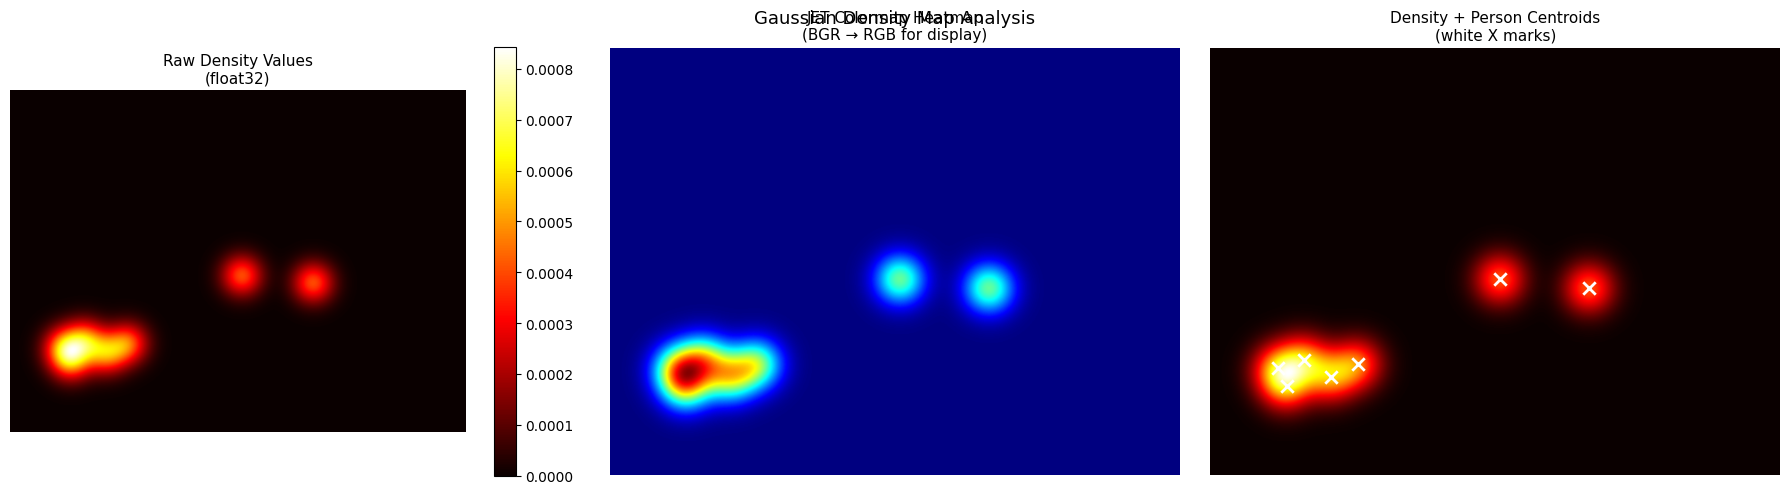

In [3]:
FRAME_HW = (480, 640)

# Build density map
density_map = build_gaussian_density_map(
    fake_detections,
    frame_hw    = FRAME_HW,
    sigma       = 20.0,
    person_only = True,
)

print("=== Gaussian Density Map ===\n")
print(f"Shape       : {density_map.shape}")
print(f"Dtype       : {density_map.dtype}")
print(f"Max value   : {density_map.max():.4f}")
print(f"Sum (≈ person count): {density_map.sum():.2f}  "
      f"(actual persons: 7)")

# Visualise
heatmap = density_to_heatmap(density_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw density values
im = axes[0].imshow(density_map, cmap="hot")
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Raw Density Values\n(float32)", fontsize=11)

# Colormapped heatmap
axes[1].imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
axes[1].set_title("JET Colormap Heatmap\n(BGR → RGB for display)",
                  fontsize=11)

# Show centroids as dots
axes[2].imshow(density_map, cmap="hot")
for det in fake_detections:
    if det.class_name == "person":
        cx, cy = det.centroid
        axes[2].scatter(cx, cy, c="white", s=80,
                        zorder=5, marker="x", linewidths=2)
axes[2].set_title("Density + Person Centroids\n(white X marks)",
                  fontsize=11)

for ax in axes:
    ax.axis("off")

plt.suptitle("Gaussian Density Map Analysis", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
grid_result = build_grid_density(
    fake_detections,
    frame_hw       = FRAME_HW,
    cell_size      = 64,
    hotspot_thresh = 2,
    class_filter   = ["person"],
)

print("=== Grid Density Result ===\n")
print(f"Grid shape    : {grid_result.grid.shape}  "
      f"({grid_result.rows} rows x {grid_result.cols} cols)")
print(f"Cell size     : {grid_result.cell_size}px")
print(f"Occupancy     : {grid_result.occupancy:.1%}  "
      f"({'HIGH' if grid_result.occupancy >= 0.6 else 'MEDIUM' if grid_result.occupancy >= 0.35 else 'LOW'})")
print(f"Max count     : {grid_result.max_count} people in one cell")
print(f"Total counted : {grid_result.total_count}")
print(f"Hotspots      : {len(grid_result.hotspots)} cells\n")

# Print grid visually
print("Grid (person counts per cell):\n")
for r in range(grid_result.rows):
    row_str = ""
    for c in range(grid_result.cols):
        val = grid_result.grid[r, c]
        if val == 0:
            row_str += "  ·"
        elif (r, c) in grid_result.hotspots:
            row_str += f" 🔴"
        else:
            row_str += f"  {val}"
    print(row_str)

print(f"\n🔴 = hotspot (>= {2} persons)")

=== Grid Density Result ===

Grid shape    : (8, 10)  (8 rows x 10 cols)
Cell size     : 64px
Occupancy     : 5.0%  (LOW)
Max count     : 3 people in one cell
Total counted : 7
Hotspots      : 2 cells

Grid (person counts per cell):

  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  1  1  ·  ·  ·
  · 🔴 🔴  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·
  ·  ·  ·  ·  ·  ·  ·  ·  ·  ·

🔴 = hotspot (>= 2 persons)


Image: 000000000061.jpg  (640x488)


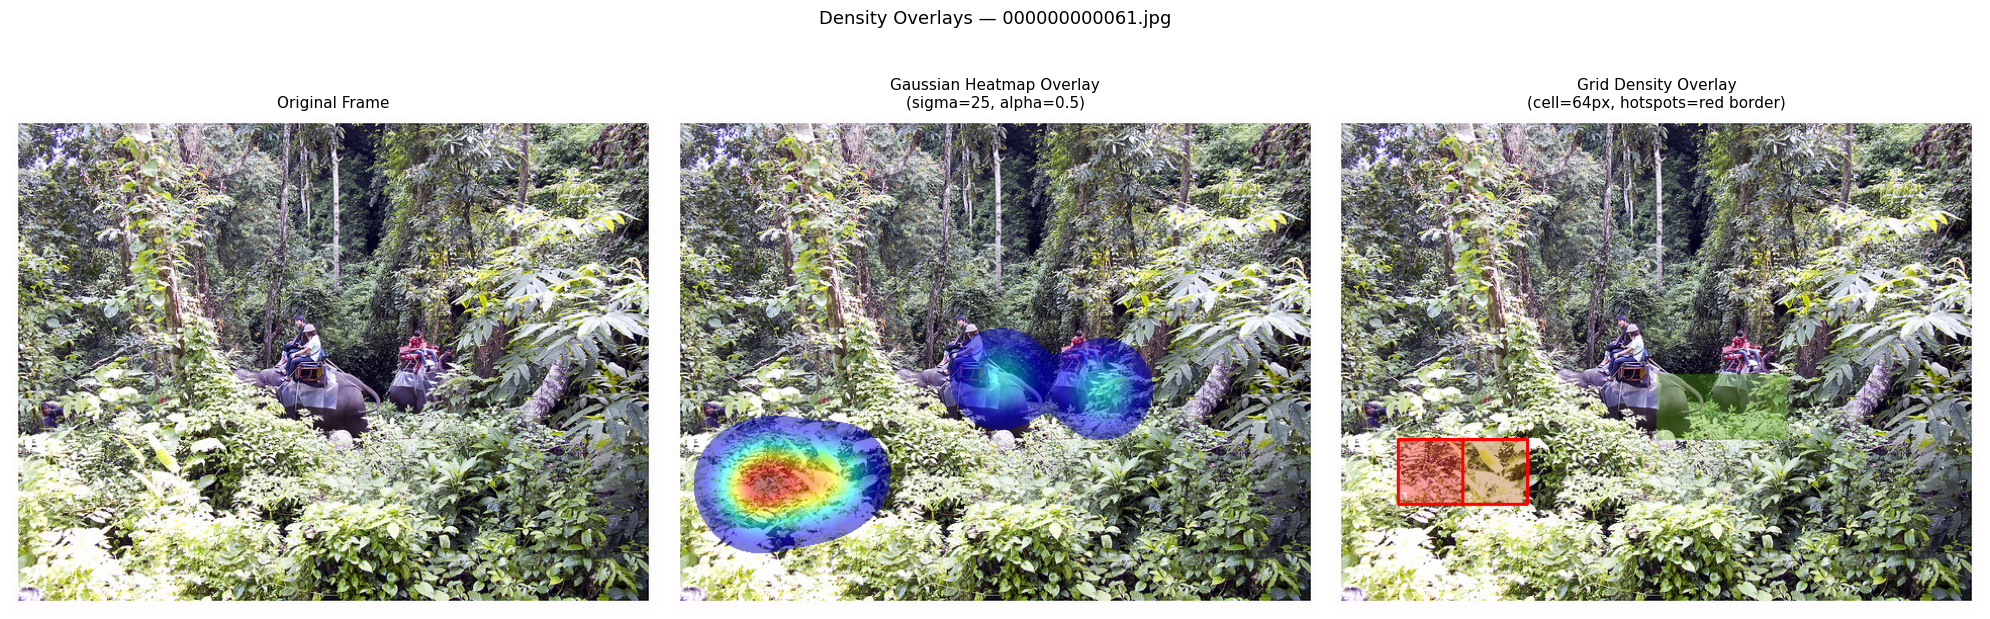

In [5]:
# Load a real image
img_dir  = cfg.TRAIN_IMG_DIR
img_name = os.listdir(img_dir)[2]
img_path = os.path.join(img_dir, img_name)
frame    = cv2.imread(img_path)
H, W     = frame.shape[:2]

print(f"Image: {img_name}  ({W}x{H})")

# Rebuild density map for this frame size
dm   = build_gaussian_density_map(
    fake_detections, (H, W), sigma=25.0
)
grid = build_grid_density(
    fake_detections, (H, W),
    cell_size=64, hotspot_thresh=2,
    class_filter=["person"]
)

# Build all overlay versions
heatmap_overlay = overlay_heatmap_on_frame(frame, dm, alpha=0.5)
grid_overlay    = overlay_grid_on_frame(
    frame, grid, alpha=0.35, show_counts=True
)

# Show all versions
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Frame", fontsize=11)

axes[1].imshow(cv2.cvtColor(heatmap_overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Gaussian Heatmap Overlay\n"
                  f"(sigma=25, alpha=0.5)", fontsize=11)

axes[2].imshow(cv2.cvtColor(grid_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Grid Density Overlay\n"
                  f"(cell=64px, hotspots=red border)", fontsize=11)

for ax in axes:
    ax.axis("off")

plt.suptitle(f"Density Overlays — {img_name}", fontsize=13)
plt.tight_layout()
plt.show()

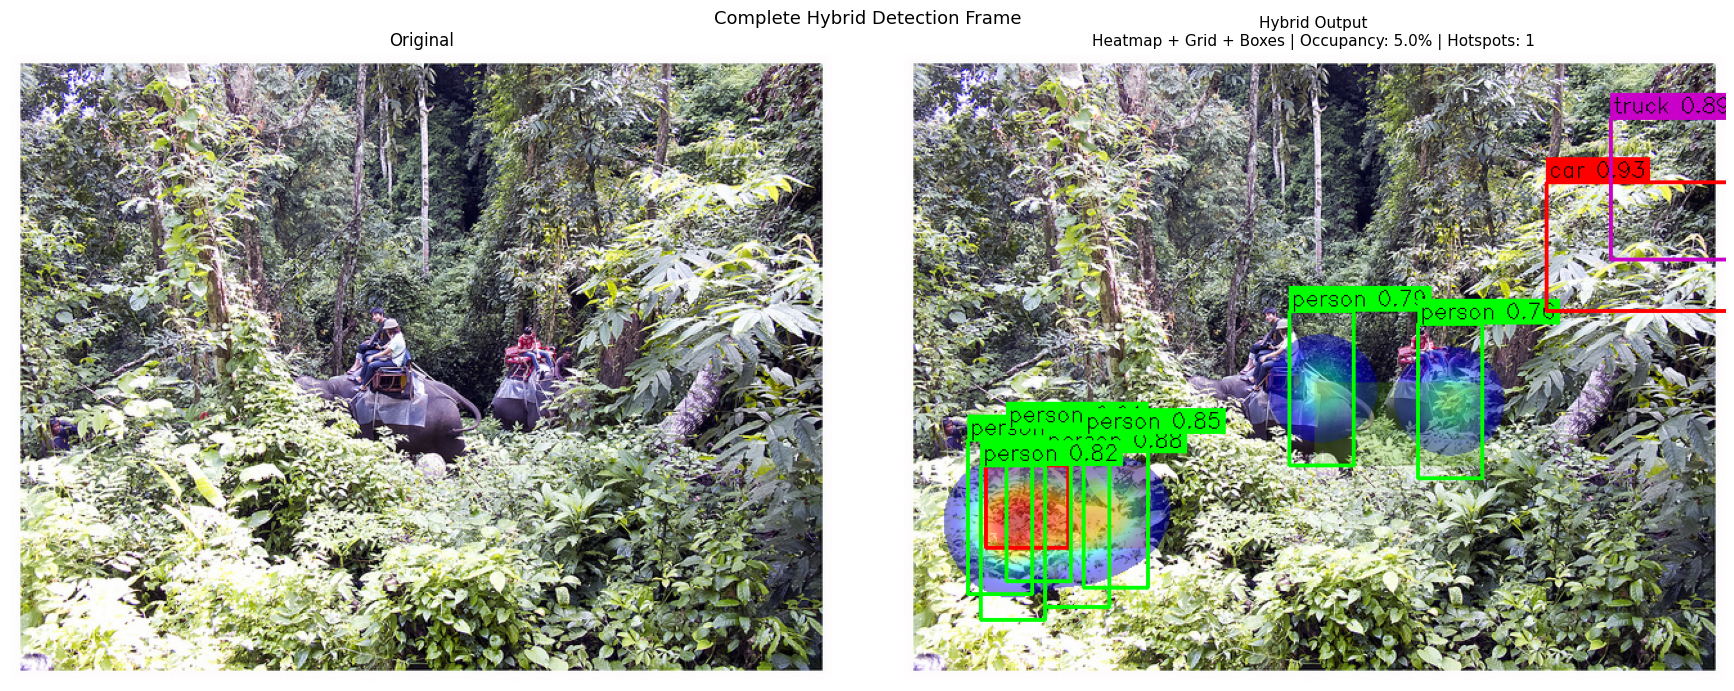


Hybrid frame summary:
  Persons detected : 7
  Grid occupancy   : 5.0%
  Hotspot cells    : 1
  Density map max  : 0.0008


In [6]:
# Build complete hybrid output
hybrid, grid_r, density = build_hybrid_frame(
    frame         = frame,
    detections    = fake_detections,
    show_heatmap  = True,
    show_grid     = True,
    show_boxes    = True,
    sigma         = 20.0,
    cell_size     = 64,
    heatmap_alpha = 0.45,
    grid_alpha    = 0.25,
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(hybrid, cv2.COLOR_BGR2RGB))
axes[1].set_title(
    f"Hybrid Output\n"
    f"Heatmap + Grid + Boxes | "
    f"Occupancy: {grid_r.occupancy:.1%} | "
    f"Hotspots: {len(grid_r.hotspots)}",
    fontsize=11
)
axes[1].axis("off")

plt.suptitle("Complete Hybrid Detection Frame", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nHybrid frame summary:")
print(f"  Persons detected : {sum(1 for d in fake_detections if d.class_name=='person')}")
print(f"  Grid occupancy   : {grid_r.occupancy:.1%}")
print(f"  Hotspot cells    : {len(grid_r.hotspots)}")
print(f"  Density map max  : {density.max():.4f}")

In [8]:
# Force reload config
import importlib
import configs.config as cfg
importlib.reload(cfg)

from configs.config import CROWD_DENSITY_HIGH, CROWD_DENSITY_MED
print(f"CROWD_DENSITY_HIGH : {CROWD_DENSITY_HIGH}")
print(f"CROWD_DENSITY_MED  : {CROWD_DENSITY_MED}")

CROWD_DENSITY_HIGH : 0.6
CROWD_DENSITY_MED  : 0.35


In [9]:
# Show how density connects to alert levels
from configs.config import (CROWD_DENSITY_HIGH, CROWD_DENSITY_MED)

print("=== Alert Threshold Analysis ===\n")
print(f"Current occupancy    : {grid_r.occupancy:.1%}")
print(f"MEDIUM threshold     : {CROWD_DENSITY_MED:.0%}")
print(f"CRITICAL threshold   : {CROWD_DENSITY_HIGH:.0%}")

if grid_r.occupancy >= CROWD_DENSITY_HIGH:
    alert = "🚨 CRITICAL — Immediate intervention needed"
elif grid_r.occupancy >= CROWD_DENSITY_MED:
    alert = "⚠️  MEDIUM — Monitor closely"
else:
    alert = "✅ LOW — Normal"

print(f"\nAlert level : {alert}")
print(f"Hotspots    : {grid_r.hotspots}")

# Simulate what gets sent to FastAPI
alert_payload = {
    "camera_id":   "cam_01",
    "timestamp":   "2024-01-01T12:00:00",
    "occupancy":   round(grid_r.occupancy, 4),
    "hotspots":    grid_r.hotspots[:5],
    "person_count": sum(1 for d in fake_detections
                        if d.class_name == "person"),
    "alert_level": "CRITICAL" if grid_r.occupancy >= CROWD_DENSITY_HIGH
                   else "MEDIUM" if grid_r.occupancy >= CROWD_DENSITY_MED
                   else "LOW",
}

import json
print(f"\nPayload sent to FastAPI:")
print(json.dumps(alert_payload, indent=2))

=== Alert Threshold Analysis ===

Current occupancy    : 5.0%
MEDIUM threshold     : 35%
CRITICAL threshold   : 60%

Alert level : ✅ LOW — Normal
Hotspots    : [(5, 1)]

Payload sent to FastAPI:
{
  "camera_id": "cam_01",
  "timestamp": "2024-01-01T12:00:00",
  "occupancy": 0.05,
  "hotspots": [
    [
      5,
      1
    ]
  ],
  "person_count": 7,
  "alert_level": "LOW"
}


In [10]:
checks = {}

# 1. Density map builds
dm = build_gaussian_density_map(
    fake_detections, FRAME_HW, sigma=15.0
)
checks["Gaussian density map builds"]    = dm.shape == FRAME_HW
checks["Density map is float32"]         = dm.dtype == np.float32
checks["Density map has non-zero values"]= dm.max() > 0

# 2. Grid builds
gr = build_grid_density(
    fake_detections, FRAME_HW,
    cell_size=64, hotspot_thresh=2
)
checks["Grid density builds"]            = gr.grid is not None
checks["Occupancy in range [0,1]"]       = 0.0 <= gr.occupancy <= 1.0
checks["Hotspots detected"]              = len(gr.hotspots) > 0

# 3. Overlays work
heat_frame = overlay_heatmap_on_frame(frame, dm)
checks["Heatmap overlay works"]          = heat_frame.shape == frame.shape

grid_frame = overlay_grid_on_frame(frame, gr)
checks["Grid overlay works"]             = grid_frame.shape == frame.shape

# 4. Hybrid frame works
hybrid, _, _ = build_hybrid_frame(frame, fake_detections)
checks["Hybrid frame builds"]            = hybrid.shape == frame.shape

# 5. DetectionResult centroid works
det = DetectionResult(np.array([50.,30.,150.,130.]), 1, 0.9, "person")
checks["Centroid computation correct"]   = det.centroid == (100, 80)

print("=== Step 9 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 10 (Full Pipeline)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 9 Checklist ===

  ✅  Gaussian density map builds
  ✅  Density map is float32
  ✅  Density map has non-zero values
  ✅  Grid density builds
  ✅  Occupancy in range [0,1]
  ✅  Hotspots detected
  ✅  Heatmap overlay works
  ✅  Grid overlay works
  ✅  Hybrid frame builds
  ✅  Centroid computation correct

All checks passed — ready for Step 10 (Full Pipeline)!
